# Plot Classwise Covariance Matrices
Load and visualize the classwise covariance matrices saved during validation.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

## Load the saved covariance matrices

In [2]:
# Set the path to your experiment directory
experiment_path = os.path.join("experiments", "scbm_residual", "CUB",
                               "Mateo_025_fixed_emp_perc_L_int_extension_loss_weight_10_2026-05-12_18-09-57_8a33c")

# Load the classwise covariances
cov_file = os.path.join(experiment_path, "classwise_covariances_residual.pt")
# or for residual model:
# cov_file = os.path.join(experiment_path, "classwise_covariances_residual.pt")

if os.path.exists(cov_file):
    classwise_covariances = torch.load(cov_file)
    print(f"Loaded covariances for {len(classwise_covariances)} classes")
    print(f"Class IDs: {sorted(classwise_covariances.keys())}")
else:
    print(f"File not found: {cov_file}")

Loaded covariances for 200 classes
Class IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199]


In [3]:
print(classwise_covariances[0])

tensor([[ 3.1028,  0.5961,  0.1628,  ...,  0.4073, -0.0185, -0.1558],
        [ 0.5961,  1.1923, -0.3352,  ...,  0.2648,  0.0508,  0.1723],
        [ 0.1628, -0.3352,  2.3337,  ...,  0.1125,  0.1995,  0.1756],
        ...,
        [ 0.4073,  0.2648,  0.1125,  ...,  6.2277,  0.2089, -0.9728],
        [-0.0185,  0.0508,  0.1995,  ...,  0.2089,  5.9737, -0.0198],
        [-0.1558,  0.1723,  0.1756,  ..., -0.9728, -0.0198,  6.6235]])


## Plot covariance matrices

In [12]:
classes = {}

class_txt_path = os.path.join("datasets", "CUB", "CUB_200_2011", "CUB_200_2011", "classes.txt")

with open(class_txt_path, "r") as f:
    for idx, line in enumerate(f):
        class_name = line.strip().split(".")[1]
        classes[idx] = class_name
        
print(classes)

{0: 'Black_footed_Albatross', 1: 'Laysan_Albatross', 2: 'Sooty_Albatross', 3: 'Groove_billed_Ani', 4: 'Crested_Auklet', 5: 'Least_Auklet', 6: 'Parakeet_Auklet', 7: 'Rhinoceros_Auklet', 8: 'Brewer_Blackbird', 9: 'Red_winged_Blackbird', 10: 'Rusty_Blackbird', 11: 'Yellow_headed_Blackbird', 12: 'Bobolink', 13: 'Indigo_Bunting', 14: 'Lazuli_Bunting', 15: 'Painted_Bunting', 16: 'Cardinal', 17: 'Spotted_Catbird', 18: 'Gray_Catbird', 19: 'Yellow_breasted_Chat', 20: 'Eastern_Towhee', 21: 'Chuck_will_Widow', 22: 'Brandt_Cormorant', 23: 'Red_faced_Cormorant', 24: 'Pelagic_Cormorant', 25: 'Bronzed_Cowbird', 26: 'Shiny_Cowbird', 27: 'Brown_Creeper', 28: 'American_Crow', 29: 'Fish_Crow', 30: 'Black_billed_Cuckoo', 31: 'Mangrove_Cuckoo', 32: 'Yellow_billed_Cuckoo', 33: 'Gray_crowned_Rosy_Finch', 34: 'Purple_Finch', 35: 'Northern_Flicker', 36: 'Acadian_Flycatcher', 37: 'Great_Crested_Flycatcher', 38: 'Least_Flycatcher', 39: 'Olive_sided_Flycatcher', 40: 'Scissor_tailed_Flycatcher', 41: 'Vermilion_Fly

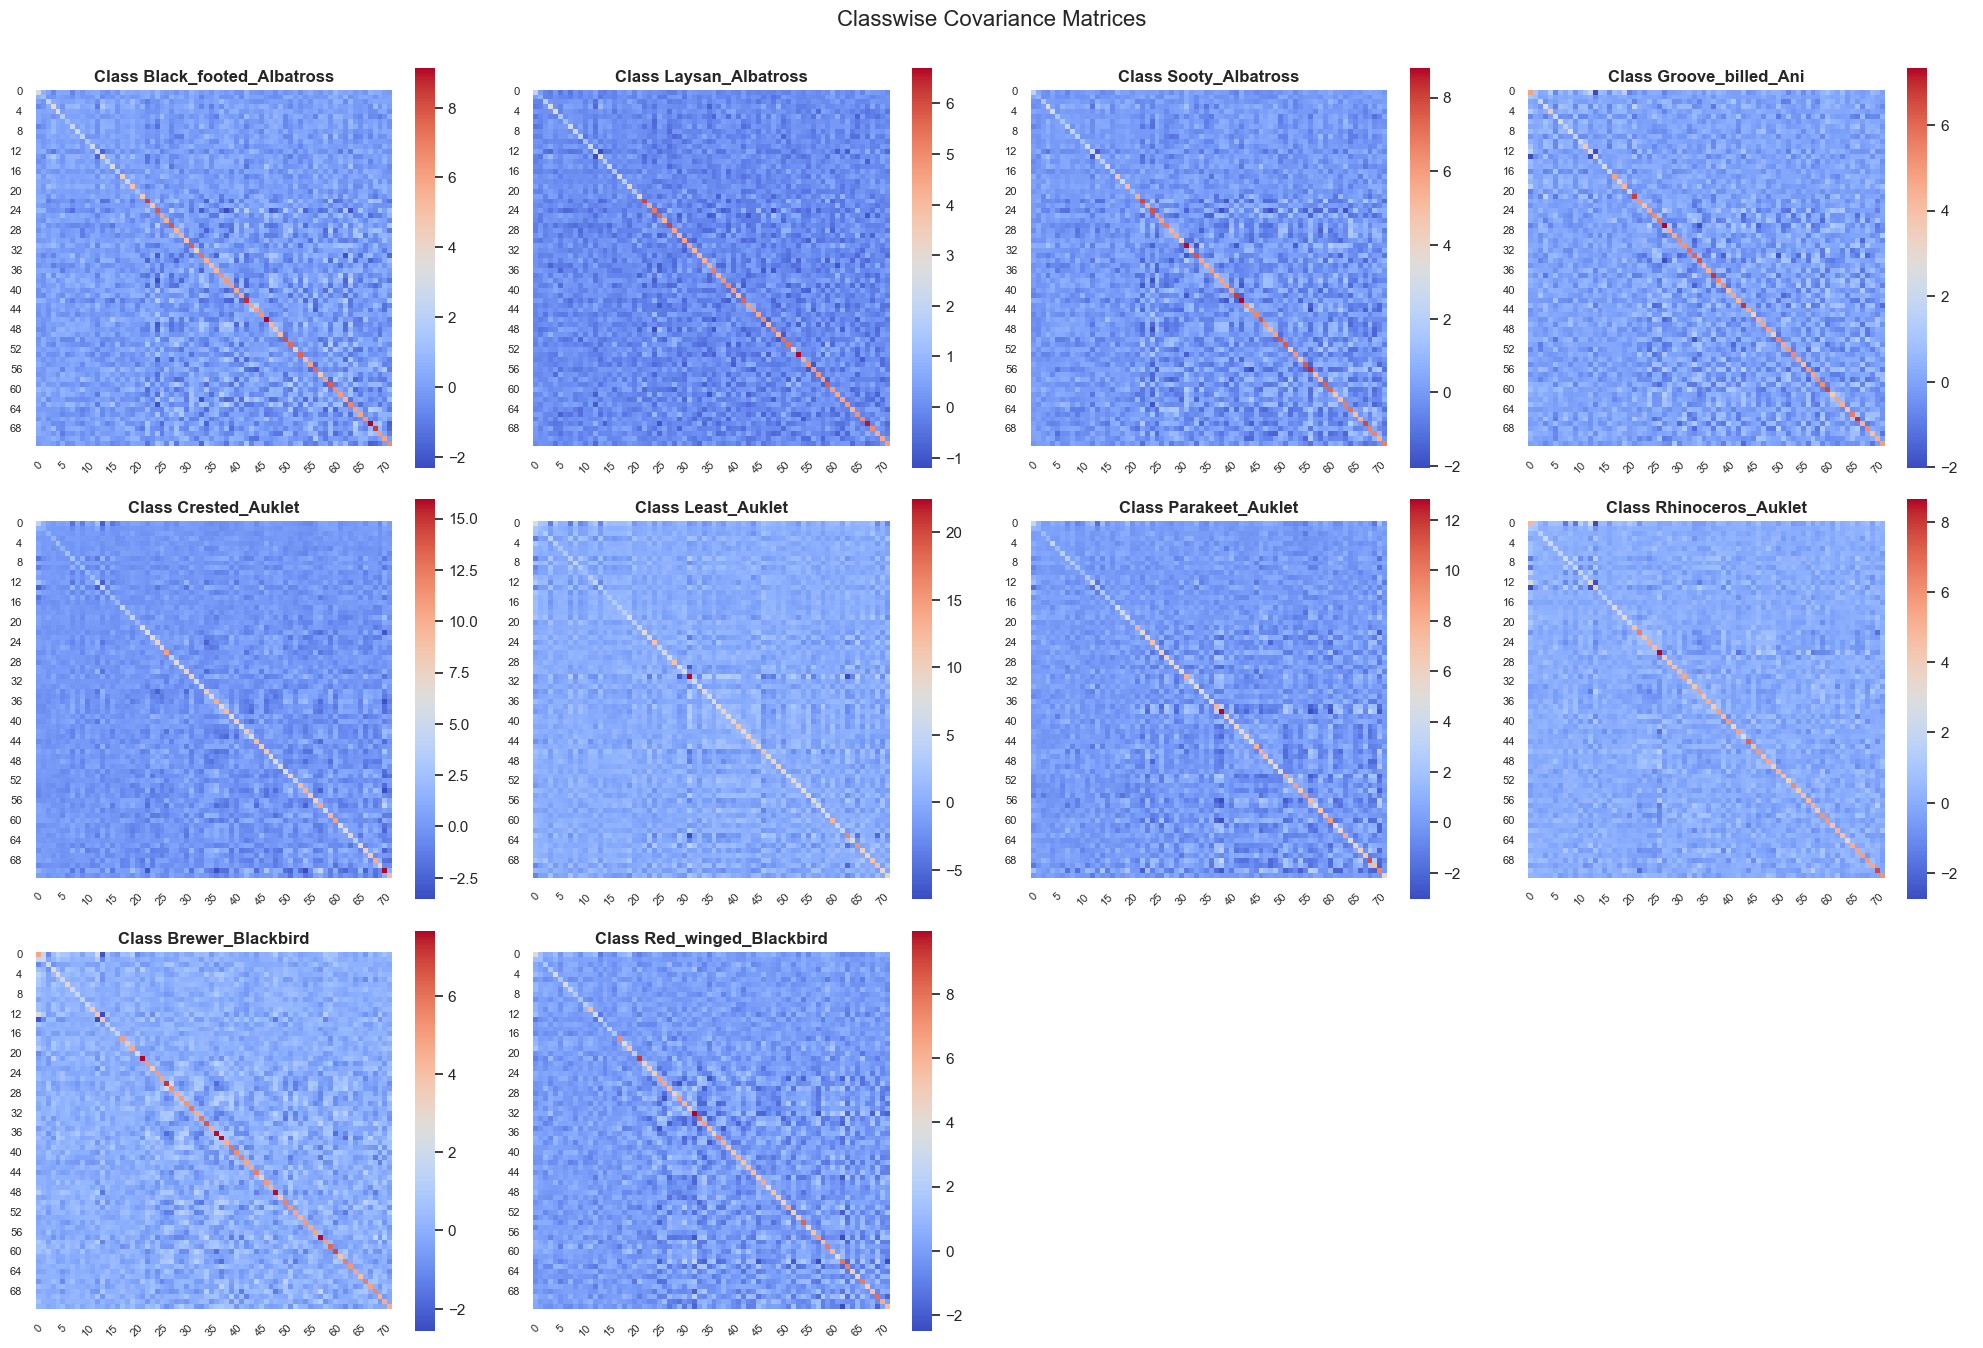

In [13]:
# Get the number of classes and concepts
n_classes = 10 #len(classwise_covariances)
n_cols = min(4, n_classes)
n_rows = int(np.ceil(n_classes / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4.5 * n_rows),
    squeeze=False,
)
sns.set_theme(style="white")

# Turn off all axes initially
for axis in axes.flat:
    axis.axis("off")

# Plot each class's covariance matrix
ordered_items = sorted(classwise_covariances.items(), key=lambda item: item[0])
for plot_idx, (class_id, cov_matrix) in enumerate(ordered_items):
    if plot_idx >= n_classes:
        break  # Only plot up to n_classes
    axis = axes.flat[plot_idx]
    axis.axis("on")

    # Convert to numpy if needed
    if hasattr(cov_matrix, "detach"):
        cov_matrix = cov_matrix.detach().cpu().numpy()
    else:
        cov_matrix = np.asarray(cov_matrix)

    # Plot heatmap
    sns.heatmap(
        cov_matrix,
        ax=axis,
        cmap="coolwarm",
        square=True,
        vmin=float(np.nanmin(cov_matrix)),
        vmax=float(np.nanmax(cov_matrix)),
        cbar=True,
    )
    axis.set_title(f"Class {classes[class_id]}", fontsize=12, fontweight="bold")
    axis.tick_params(axis="x", rotation=45, labelsize=8)
    axis.tick_params(axis="y", rotation=0, labelsize=8)

# Turn off unused subplots
for axis in axes.flat[n_classes:]:
    axis.axis("off")

fig.suptitle("Classwise Covariance Matrices", fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

## Plot correlation matrices instead

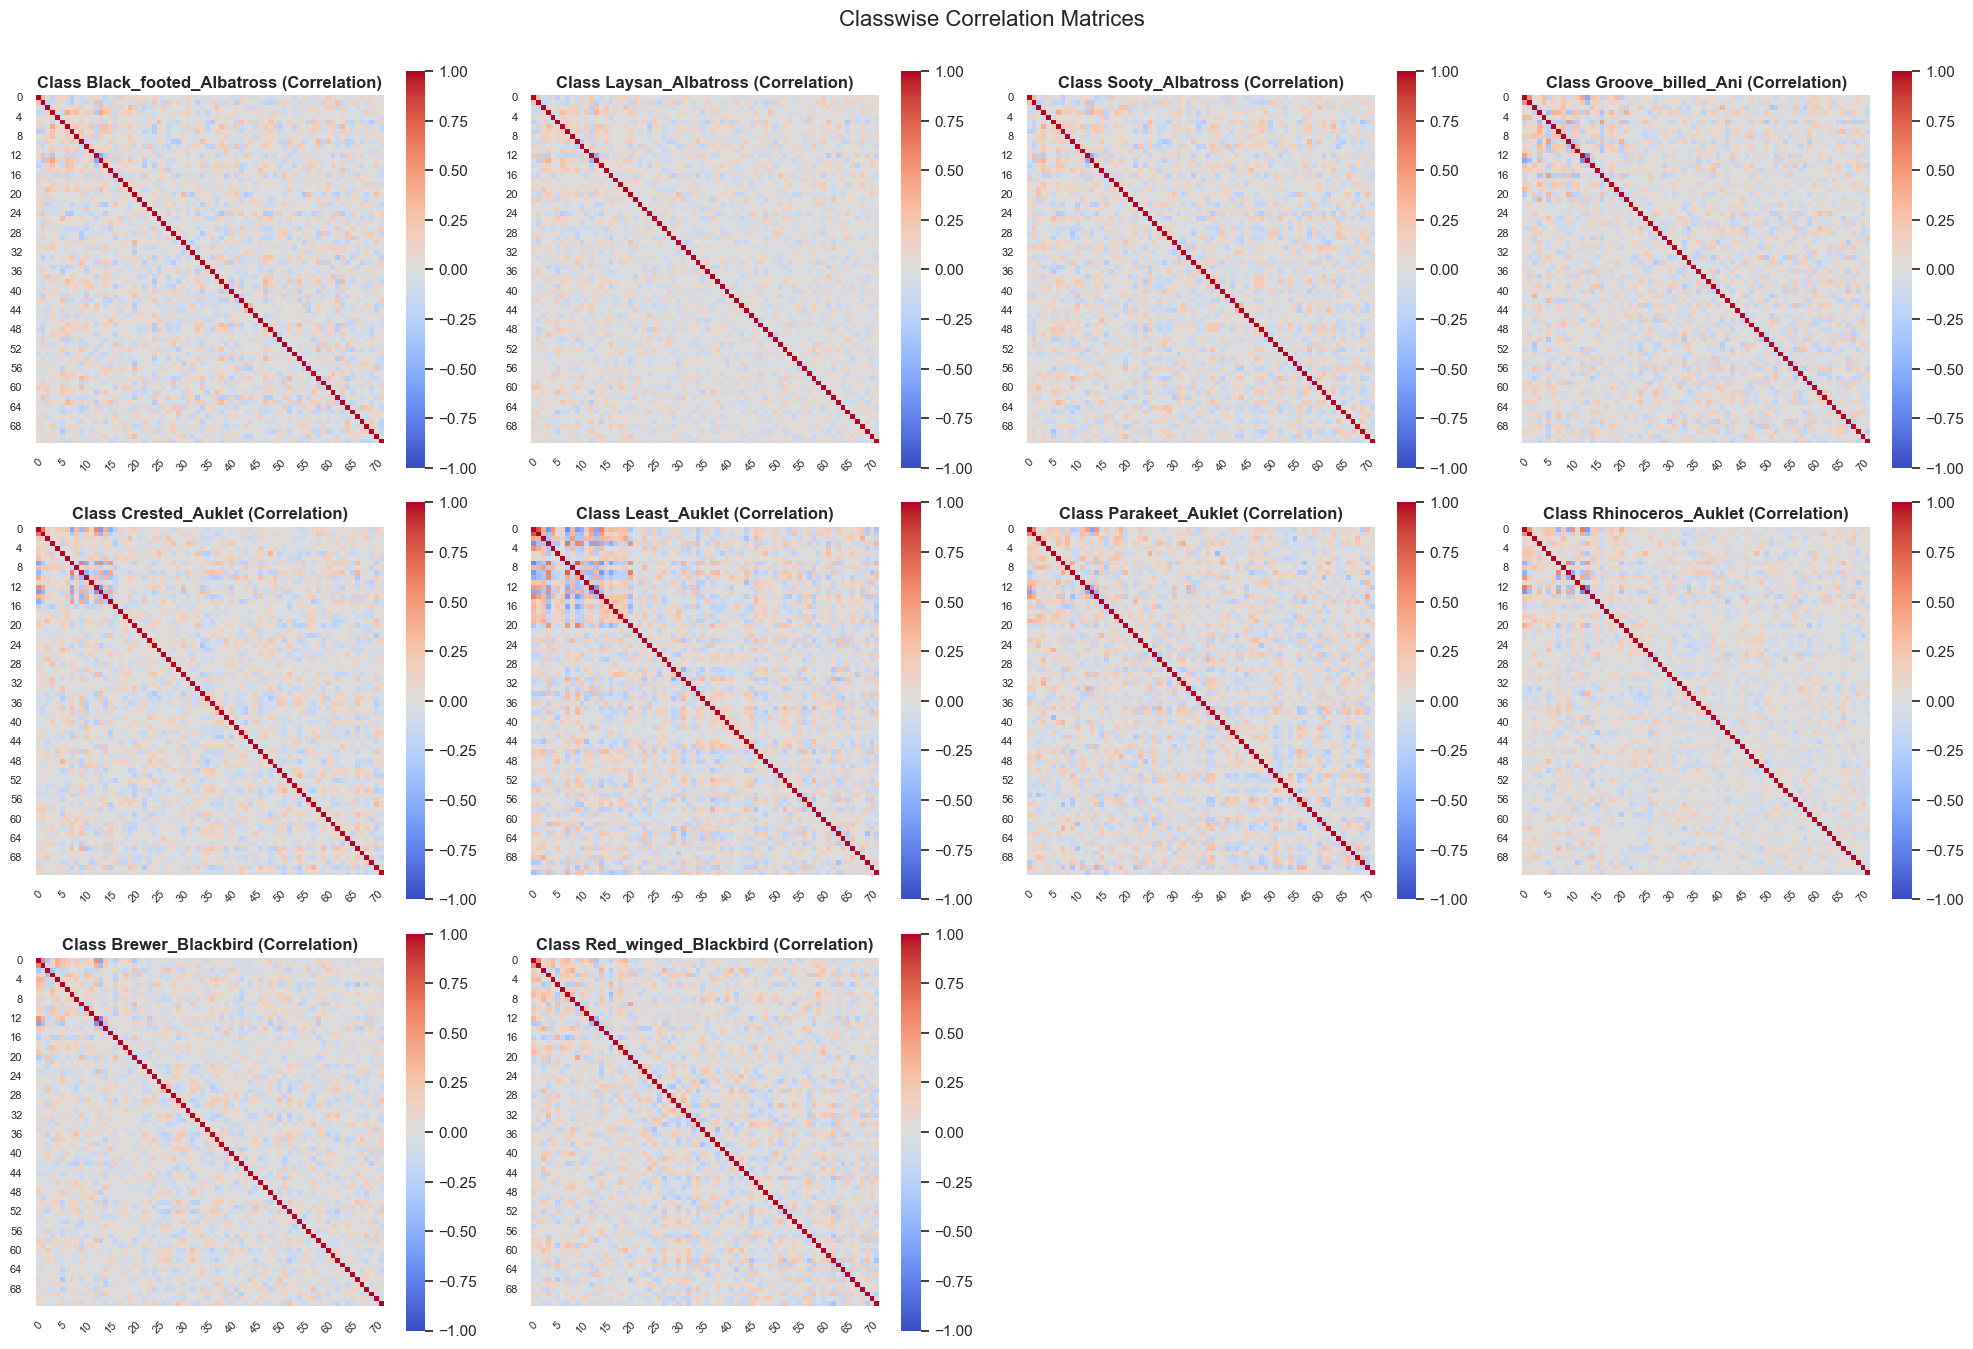

In [15]:
# Convert covariance to correlation
def cov_to_corr(cov_matrix):
    """Convert covariance matrix to correlation matrix."""
    if hasattr(cov_matrix, "numpy"):
        cov_matrix = cov_matrix.numpy()
    std = np.sqrt(np.diag(np.diag(cov_matrix)))
    corr = np.linalg.inv(std) @ cov_matrix @ np.linalg.inv(std)
    return corr

n_classes = 10 #len(classwise_covariances)
n_cols = min(4, n_classes)
n_rows = int(np.ceil(n_classes / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4.5 * n_rows),
    squeeze=False,
)
sns.set_theme(style="white")

for axis in axes.flat:
    axis.axis("off")

ordered_items = sorted(classwise_covariances.items(), key=lambda item: item[0])
for plot_idx, (class_id, cov_matrix) in enumerate(ordered_items):
    if plot_idx >= n_classes:
        break  # Only plot up to n_classes
    axis = axes.flat[plot_idx]
    axis.axis("on")

    # Convert to correlation
    corr_matrix = cov_to_corr(cov_matrix)

    # Plot heatmap
    sns.heatmap(
        corr_matrix,
        ax=axis,
        cmap="coolwarm",
        square=True,
        vmin=-1,
        vmax=1,
        cbar=True,
    )
    axis.set_title(f"Class {classes[class_id]} (Correlation)", fontsize=12, fontweight="bold")
    axis.tick_params(axis="x", rotation=45, labelsize=8)
    axis.tick_params(axis="y", rotation=0, labelsize=8)

for axis in axes.flat[n_classes:]:
    axis.axis("off")

fig.suptitle("Classwise Correlation Matrices", fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

# Correlation of just concepts

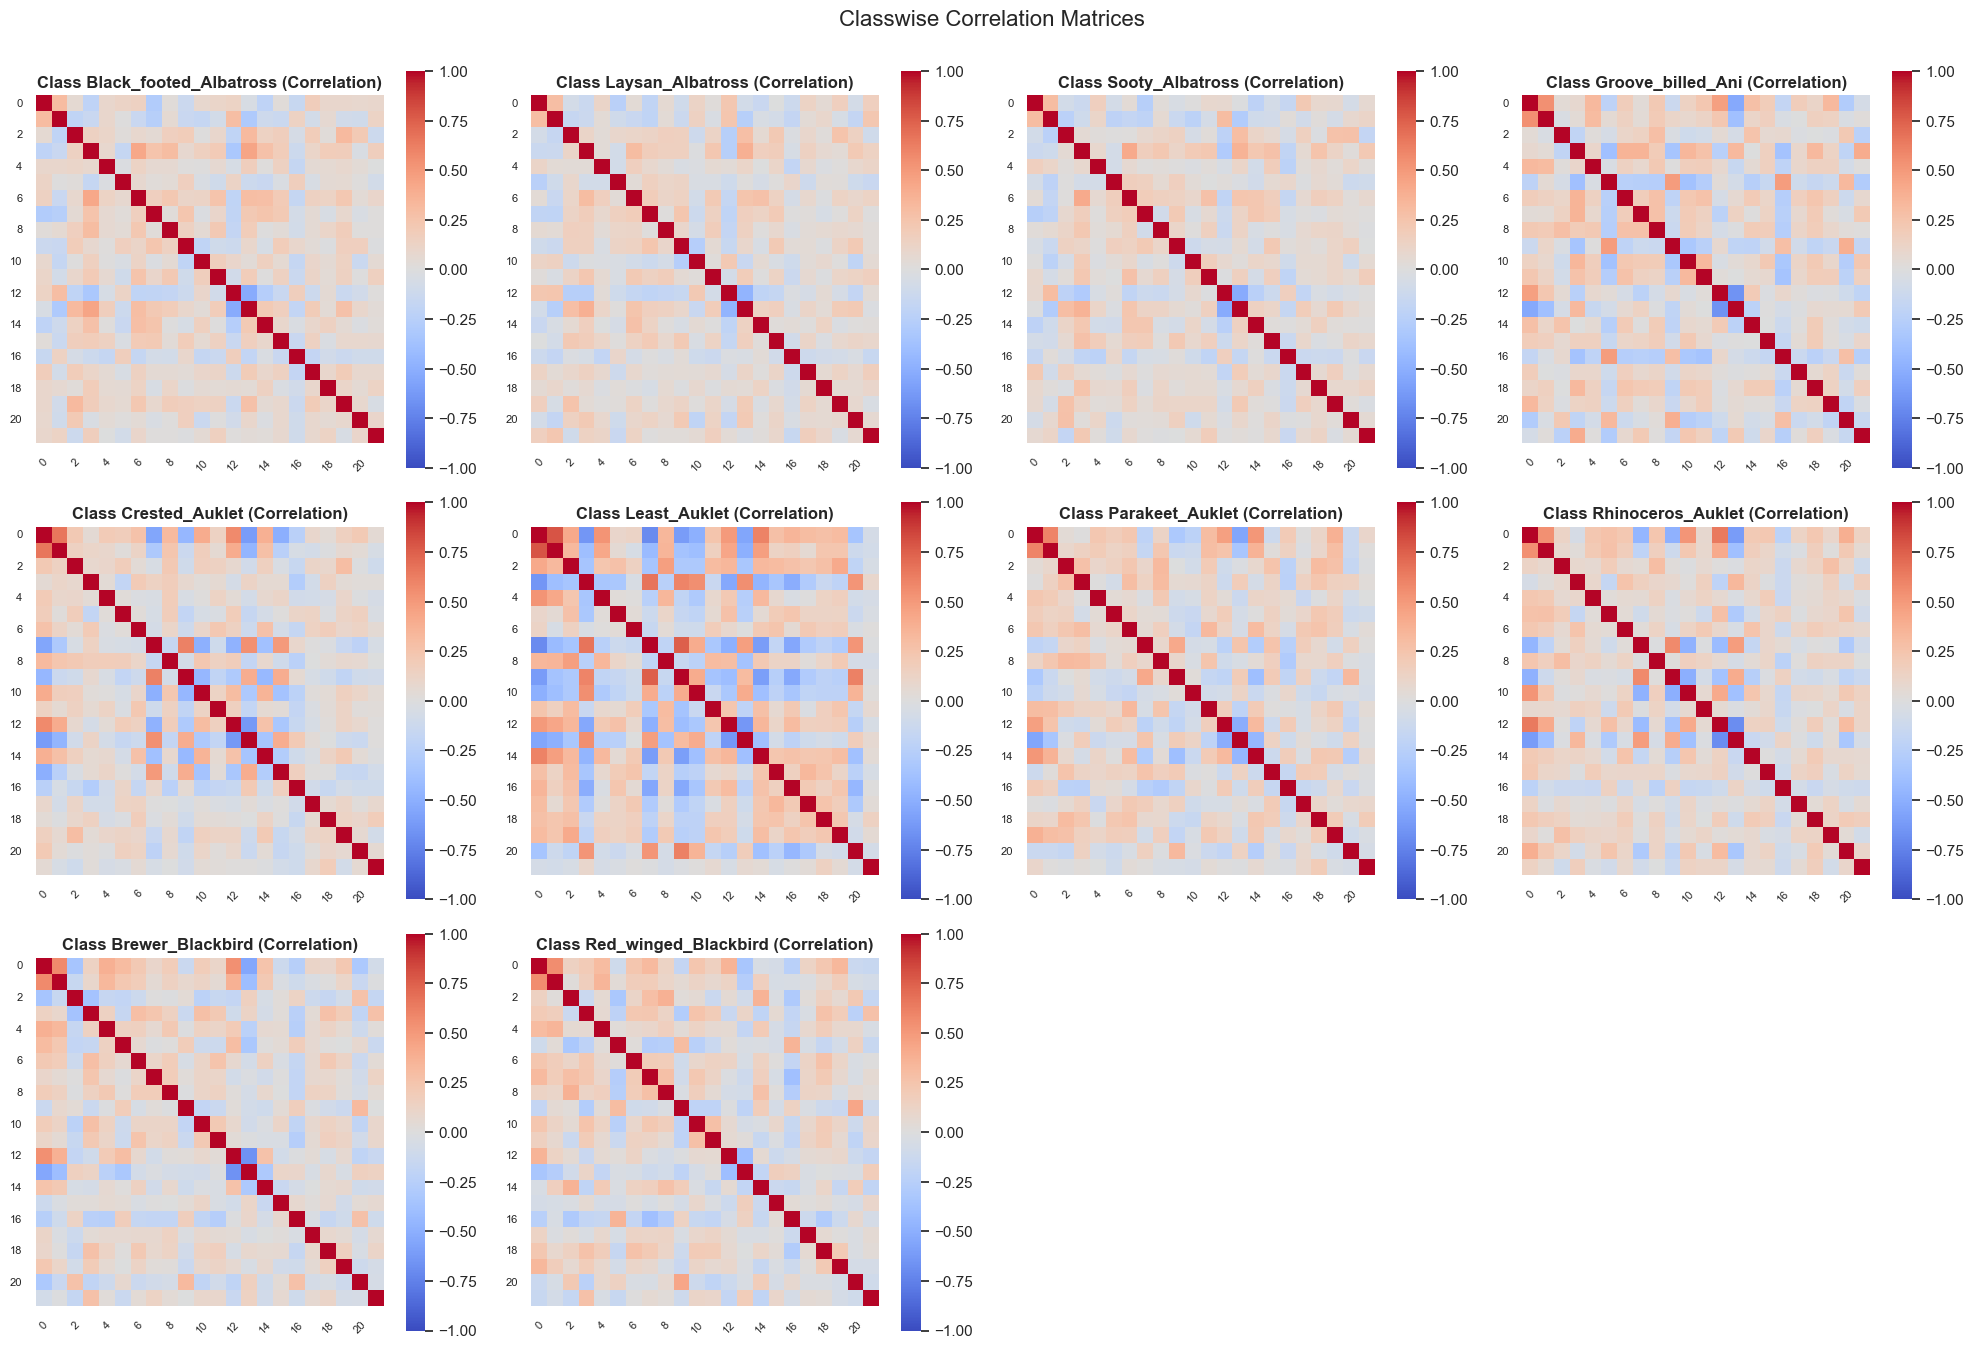

In [17]:
# Convert covariance to correlation
def cov_to_corr(cov_matrix):
    """Convert covariance matrix to correlation matrix."""
    if hasattr(cov_matrix, "numpy"):
        cov_matrix = cov_matrix.numpy()
    std = np.sqrt(np.diag(np.diag(cov_matrix)))
    corr = np.linalg.inv(std) @ cov_matrix @ np.linalg.inv(std)
    return corr

n_classes = 10 #len(classwise_covariances)
n_cols = min(4, n_classes)
n_rows = int(np.ceil(n_classes / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4.5 * n_rows),
    squeeze=False,
)
sns.set_theme(style="white")

for axis in axes.flat:
    axis.axis("off")

ordered_items = sorted(classwise_covariances.items(), key=lambda item: item[0])
for plot_idx, (class_id, cov_matrix) in enumerate(ordered_items):
    if plot_idx >= n_classes:
        break  # Only plot up to n_classes
    axis = axes.flat[plot_idx]
    axis.axis("on")

    # Convert to correlation
    corr_matrix = cov_to_corr(cov_matrix)
    
    # Extract only the first 22 concepts 
    num_concepts = 22
    slice_concepts = slice(0, num_concepts)
    corr_matrix = corr_matrix[slice_concepts, slice_concepts]
    
    


    # Plot heatmap
    sns.heatmap(
        corr_matrix,
        ax=axis,
        cmap="coolwarm",
        square=True,
        vmin=-1,
        vmax=1,
        cbar=True,
    )
    axis.set_title(f"Class {classes[class_id]} (Correlation)", fontsize=12, fontweight="bold")
    axis.tick_params(axis="x", rotation=45, labelsize=8)
    axis.tick_params(axis="y", rotation=0, labelsize=8)

for axis in axes.flat[n_classes:]:
    axis.axis("off")

fig.suptitle("Classwise Correlation Matrices", fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

## Summary statistics per class

In [ ]:
import pandas as pd

summary_data = []
for class_id, cov_matrix in sorted(classwise_covariances.items()):
    if hasattr(cov_matrix, "numpy"):
        cov_matrix = cov_matrix.numpy()
    
    summary_data.append({
        "Class ID": class_id,
        "Trace (sum of diagonal)": float(np.trace(cov_matrix)),
        "Determinant": float(np.linalg.det(cov_matrix)),
        "Max eigenvalue": float(np.max(np.linalg.eigvals(cov_matrix))),
        "Condition number": float(np.linalg.cond(cov_matrix)),
        "Frobenius norm": float(np.linalg.norm(cov_matrix, 'fro')),
    })

summary_df = pd.DataFrame(summary_data)
display(summary_df)